# Chromosome IV Replicate 1 - Prototype Replication Deconvolution

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
from src.RealDataReplication import RealDataReplicationDeconvolution
from src.config import load_default_chrom_configs


In [7]:
config, _ = load_default_chrom_configs()
real_deconv1 = RealDataReplicationDeconvolution(config, replicate=1, chr=4)

todo: Loading testing config from replication deconvolution
Threshold windows with less than 75% read coverage.


In [53]:
real_deconv1.setup_deconvolution(real_deconv1.config)

Initializing N using config H.
Initializing B using timepoint 0


In [54]:
_ = real_deconv1.iterative_deconvolution_updates(20, verbose=False)

Iteration 0
0/702 - 00:00:00.018
100/702 - 00:00:00.095
200/702 - 00:00:00.165
300/702 - 00:00:00.297
400/702 - 00:00:00.387
500/702 - 00:00:00.498
600/702 - 00:00:00.720
700/702 - 00:00:00.872
Iteration completed 00:00:02.433, rn=0.0062385955459342765
Iteration 1
0/702 - 00:00:02.474
100/702 - 00:00:02.639
200/702 - 00:00:02.897
300/702 - 00:00:03.055
400/702 - 00:00:03.142
500/702 - 00:00:03.243
600/702 - 00:00:03.355
700/702 - 00:00:03.475
Iteration completed 00:00:05.102, rn=0.004071735332399822
Iteration 2
0/702 - 00:00:05.234
100/702 - 00:00:05.505
200/702 - 00:00:05.657
300/702 - 00:00:05.878
400/702 - 00:00:06.010
500/702 - 00:00:06.160
600/702 - 00:00:06.408
700/702 - 00:00:06.612
Iteration completed 00:00:07.767, rn=0.00342823763888512
Iteration 3
0/702 - 00:00:07.810
100/702 - 00:00:07.919
200/702 - 00:00:08.145
300/702 - 00:00:08.226
400/702 - 00:00:08.377
500/702 - 00:00:08.551
600/702 - 00:00:08.728
700/702 - 00:00:08.882
Iteration completed 00:00:09.974, rn=0.00324690566

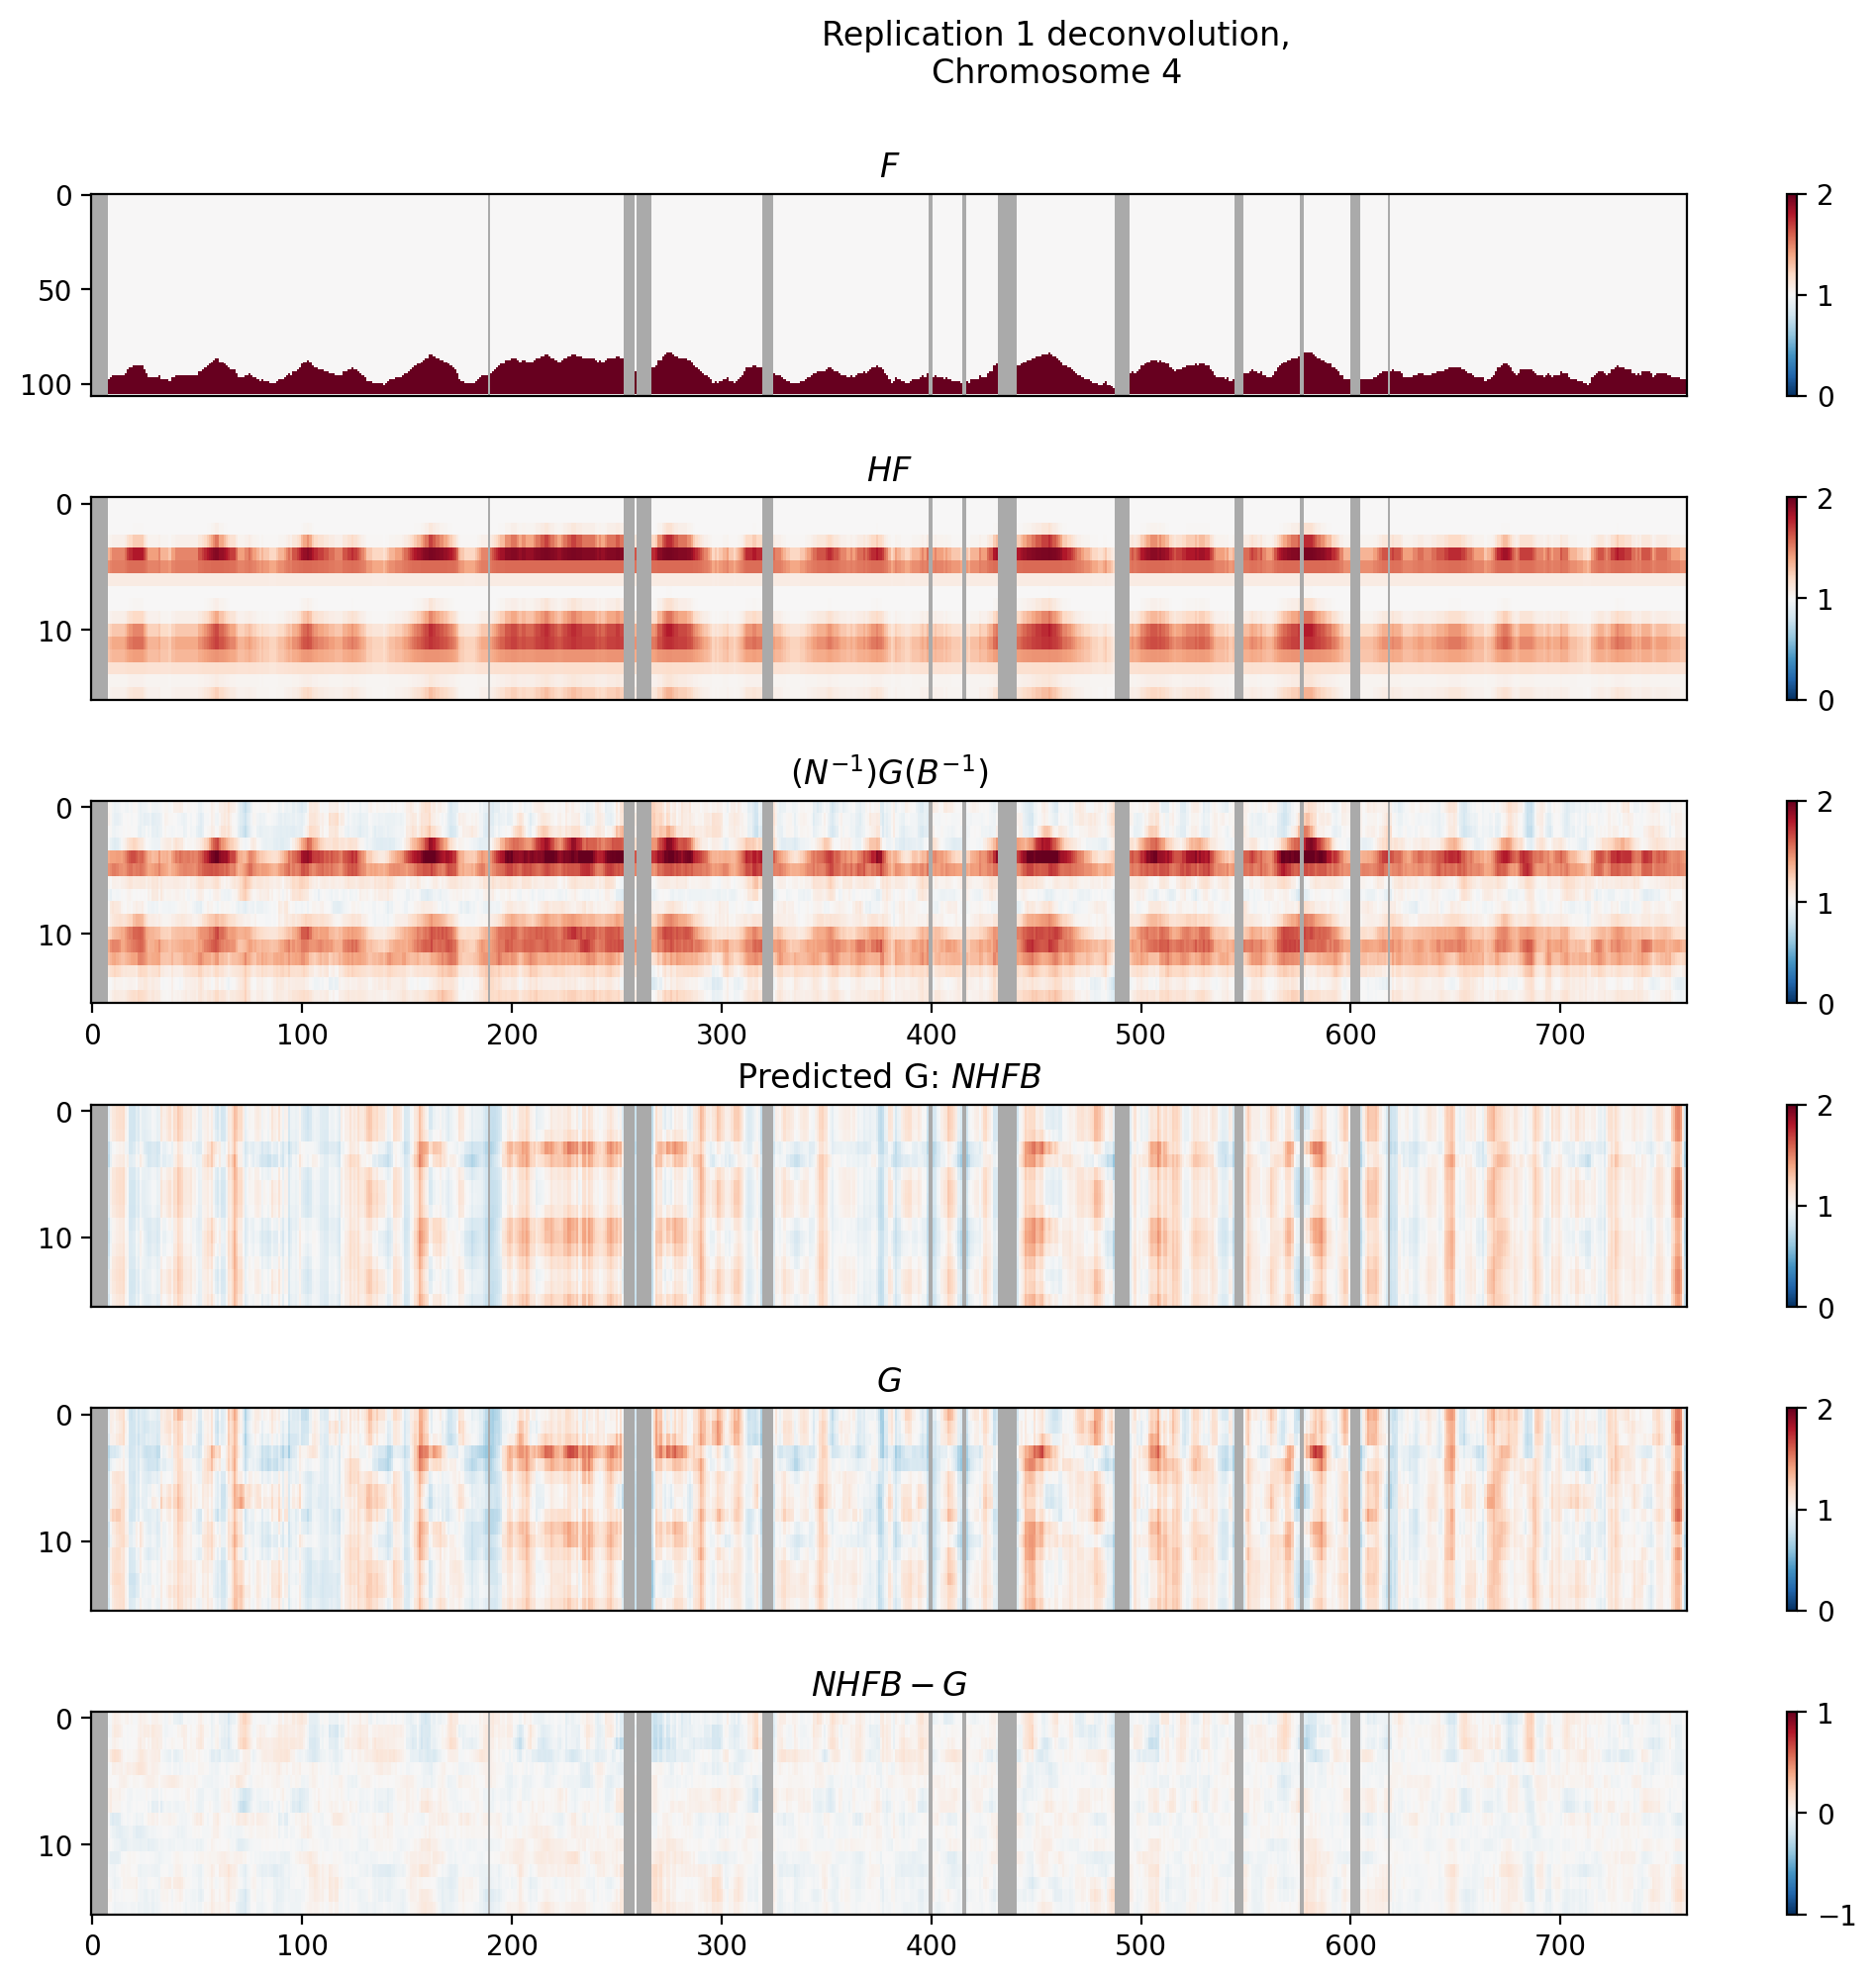

In [55]:
fig = real_deconv1.plot_heatmaps()

In [58]:
save_directory = 'output/replication_profiles_trial'
real_deconv1.save_to_disk(save_directory)

Creating directory: output/replication_profiles_trial...Directory exists. Skipping.
Saved to: output/replication_profiles_trial/rep1_chr4_N.npy
Saved to: output/replication_profiles_trial/rep1_chr4_B.npy
Saved to: output/replication_profiles_trial/rep1_chr4_H.npy
Saved to: output/replication_profiles_trial/rep1_chr4_F.npy
Saved to: output/replication_profiles_trial/rep1_chr4_parameters.csv
Saved to: output/replication_profiles_trial/rep1_chr4.png


In [88]:
from src.timer import Timer

config, _ = load_default_chrom_configs('distinct')
config.calculate_H()

timer = Timer()    
for chrom in range(1, 17):
    print("Chromosome", chrom)
    real_deconv1 = RealDataReplicationDeconvolution(config, replicate=1, chr=chrom)
    real_deconv1.setup_deconvolution()
    
    _ = real_deconv1.iterative_deconvolution_updates(20, verbose=False)
    real_deconv1.save_to_disk(save_directory)
    timer.print_time()


todo: Loading testing config from replication deconvolution
Chromosome 1
Threshold windows with less than 75% read coverage.
Initializing N using config H.
Initializing B using timepoint 0
Creating directory: output/replication_profiles_trial...Directory exists. Skipping.
Saved to: output/replication_profiles_trial/rep1_chr1_N.npy
Saved to: output/replication_profiles_trial/rep1_chr1_B.csv
Saved to: output/replication_profiles_trial/rep1_chr1_H.npy
Saved to: output/replication_profiles_trial/rep1_chr1_F.csv
Saved to: output/replication_profiles_trial/rep1_chr1_parameters.csv
Saved to: output/replication_profiles_trial/rep1_chr1.png
00:00:16.522
Chromosome 2
Threshold windows with less than 75% read coverage.
Initializing N using config H.
Initializing B using timepoint 0
Creating directory: output/replication_profiles_trial...Directory exists. Skipping.
Saved to: output/replication_profiles_trial/rep1_chr2_N.npy
Saved to: output/replication_profiles_trial/rep1_chr2_B.csv
Saved to: outp

Saved to: output/replication_profiles_trial/rep1_chr14_F.csv
Saved to: output/replication_profiles_trial/rep1_chr14_parameters.csv
Saved to: output/replication_profiles_trial/rep1_chr14.png
00:11:06.952
Chromosome 15
Threshold windows with less than 75% read coverage.
Initializing N using config H.
Initializing B using timepoint 0
Creating directory: output/replication_profiles_trial...Directory exists. Skipping.
Saved to: output/replication_profiles_trial/rep1_chr15_N.npy
Saved to: output/replication_profiles_trial/rep1_chr15_B.csv
Saved to: output/replication_profiles_trial/rep1_chr15_H.npy
Saved to: output/replication_profiles_trial/rep1_chr15_F.csv
Saved to: output/replication_profiles_trial/rep1_chr15_parameters.csv
Saved to: output/replication_profiles_trial/rep1_chr15.png
00:12:05.289
Chromosome 16
Threshold windows with less than 75% read coverage.
Initializing N using config H.
Initializing B using timepoint 0
Creating directory: output/replication_profiles_trial...Directory e

In [89]:
from src.RealDataReplication import read_n_fr_b

N, frep, b = read_n_fr_b(1, (12000, 12001))
# replicate = 1
# chrom = 1

# N = np.load(f'{save_directory}/rep{replicate}_chr{chrom}_N.npy')
# Fr_df = pd.read_csv(f'{save_directory}/rep{replicate}_chr{chrom}_F.csv')
# Fr_df = Fr_df[Fr_df.columns[1:]]
# Fr_df.columns = Fr_df.columns.astype(int)

# B_df = pd.read_csv(f'{save_directory}/rep{replicate}_chr{chrom}_B.csv')
# B_df = B_df[B_df.columns[1:]]
# B_df.columns = B_df.columns.astype(int)
# B_df = B_df.T



Loading trial replication profile, 2/17/25


ValueError: too many values to unpack (expected 3)

In [ ]:
config.H.shape

In [ ]:
Fr_df.shape